In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [3]:
data_dir = "dataset"

print(os.listdir(data_dir))

['daisy', 'dandelion', 'LICENSE.txt', 'roses', 'sunflowers', 'tulips']


In [4]:
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

daisy : 633
dandelion : 898
roses : 641
sunflowers : 699
tulips : 799


In [5]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [7]:
class_names = train_ds.class_names

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


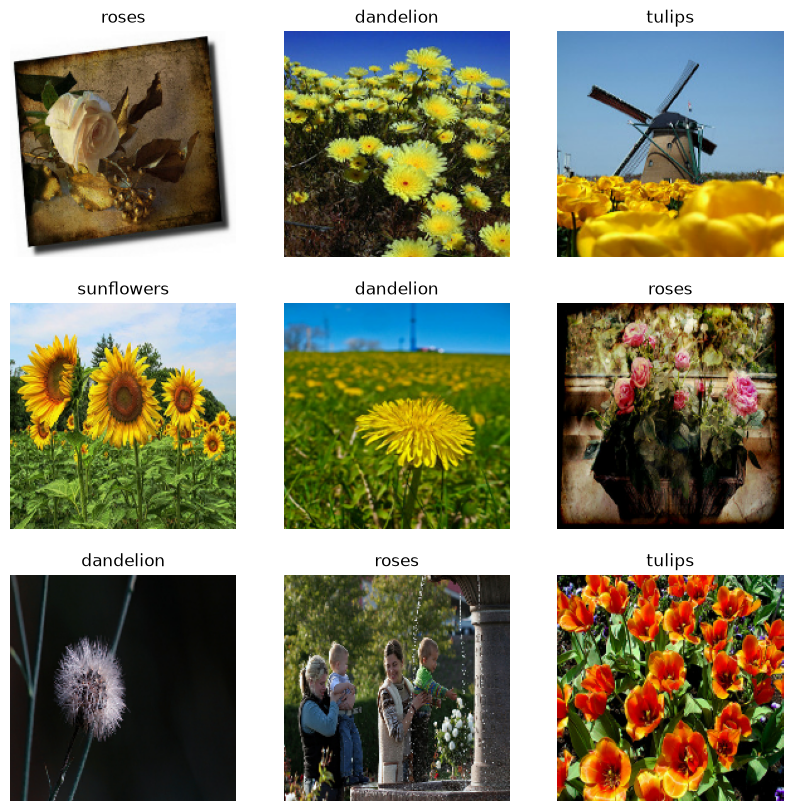

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

for images, labels in train_ds.take(1):
    print("Before:", images[0][0][0])

    normalized_images = normalization_layer(images)

    print("After:", normalized_images[0][0][0])

Before: tf.Tensor([ 88.388885 124.388885 200.38889 ], shape=(3,), dtype=float32)
After: tf.Tensor([0.3466231  0.48779958 0.78583884], shape=(3,), dtype=float32)


In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [13]:
model = tf.keras.Sequential([
    
    data_augmentation,
    
    normalization_layer,
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    
    tf.keras.layers.Dense(5, activation="softmax")
])

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\PRANJAL\OneDrive\Desktop\flower\.venv-1\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 670ms/step - accuracy: 0.4057 - loss: 1.3782 - val_accuracy: 0.5204 - val_loss: 1.1432
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 423ms/step - accuracy: 0.5562 - loss: 1.0958 - val_accuracy: 0.5790 - val_loss: 1.0643
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 647ms/step - accuracy: 0.6192 - loss: 0.9760 - val_accuracy: 0.6281 - val_loss: 0.9435
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 398ms/step - accuracy: 0.6451 - loss: 0.9100 - val_accuracy: 0.6512 - val_loss: 0.8685
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 448ms/step - accuracy: 0.6832 - loss: 0.8401 - val_accuracy: 0.6335 - val_loss: 0.8862
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6856 - loss: 0.7889 - val_accuracy: 0.6785 - val_loss: 0.8059
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7238 - loss: 0.7301 - val_accuracy: 0.6866 - val_loss: 0.7725
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7381 - loss: 0.6998 - val_accuracy: 0.7084 - va

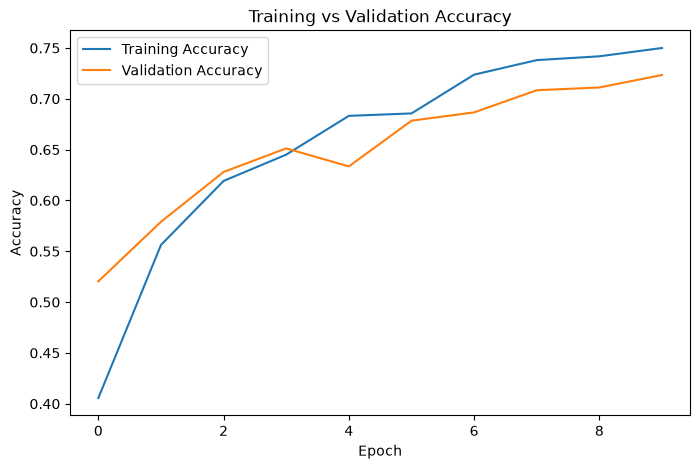

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

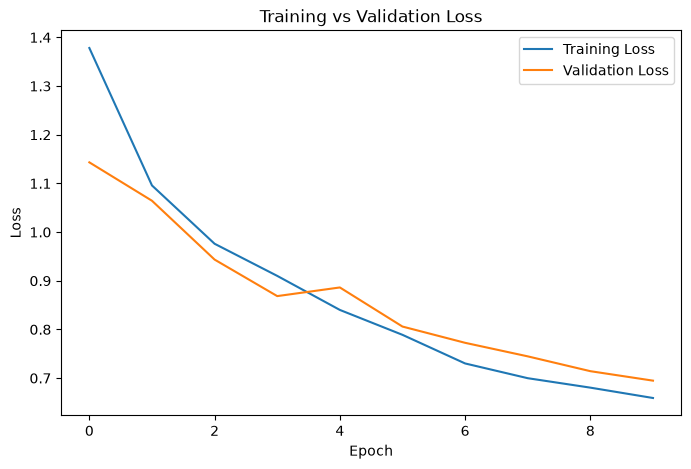

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [21]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7234 - loss: 0.6948
Validation Loss: 0.6947624087333679
Validation Accuracy: 0.723433256149292


In [22]:
model.save("flower_model.keras")

In [23]:
import os

print(os.path.exists("flower_model.keras"))

True


In [24]:
import os
import random

class_name = random.choice(class_names)
folder = os.path.join(data_dir, class_name)

image_name = random.choice(os.listdir(folder))
image_path = os.path.join(folder, image_name)

print("Actual class:", class_name)
print("Image path:", image_path)

Actual class: dandelion
Image path: dataset\dandelion\14648777167_1d92d403c9_n.jpg


In [25]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

In [26]:
img_array = tf.expand_dims(img_array, 0)

In [27]:
predictions = model.predict(img_array)

score = tf.nn.softmax(predictions[0])

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted class: dandelion
Confidence: 29.92 %


In [28]:
class_names[np.argmax(score)]

'dandelion'